### Import Packages and connect to DB

In [1]:
import warnings
warnings.filterwarnings('ignore')

from datetime import date
import seaborn as sns 
import matplotlib.pyplot as plt
import pandas as pd 
import numpy as np
import pyodbc 
import math

from IPython.display import display

In [127]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from parentHelpers import *
from databaseHelpers import *
from helperProjectSwift import *
from regression import *

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
# from sklearn.model_selection import train_test_split
# from sklearn.linear_model import LinearRegression
# from sklearn.inspection import permutation_importance
# import matplotlib.pyplot as plt
# from sklearn.linear_model import LogisticRegression
# from sklearn.metrics import accuracy_score
# from sklearn.metrics import roc_auc_score, make_scorer
# from sklearn.preprocessing import StandardScaler

### Connect to Database

In [4]:
query_candidates = [
    Path("sqls") / "sql_query_for_regression.txt",
    Path("Project Swift Lloyds") / "sqls" / "sql_query_for_regression.txt",
]
query_path = next(path for path in query_candidates if path.exists())
query = query_path.read_text(encoding="utf-8")

In [5]:
LoanTapeRaw = connect_db(query)

In [6]:
# display(LoanTapeRaw)

In [7]:
LoanTape = clean_loan_tape(LoanTapeRaw)

# display(LoanTape.head())

df = LoanTape.copy()   # Your actual dataframe
# df['EverD60CO'] = df['EverD60CO_Mar2026']  # We want to analyze the Mar2026 outcome

Duplicated Loan Count:  32
Final Loan Tape Shape:  (310681, 153)


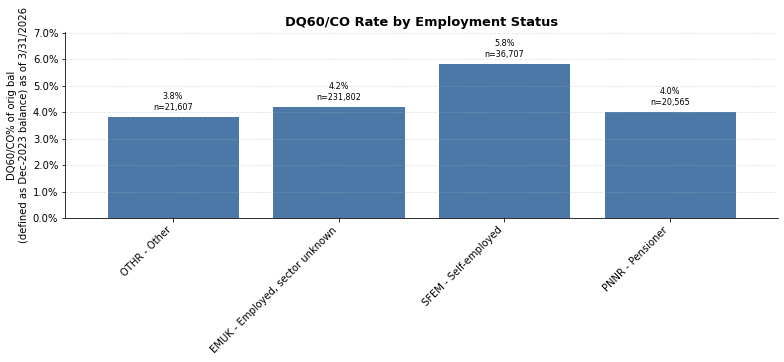

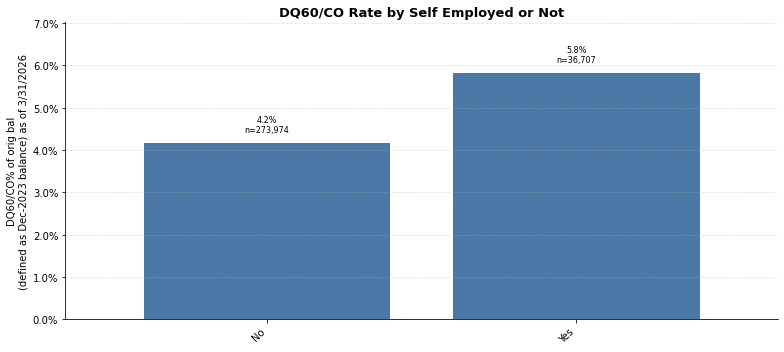

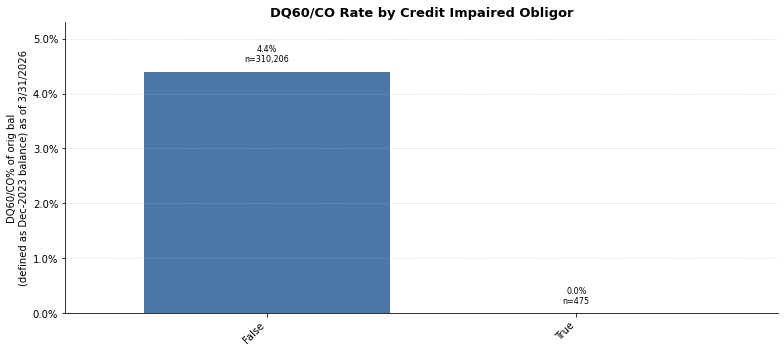

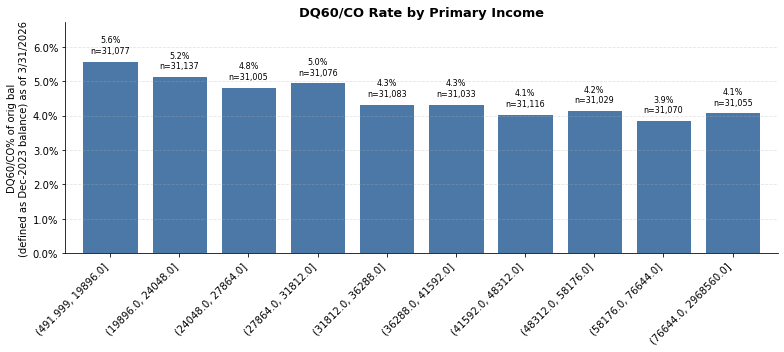

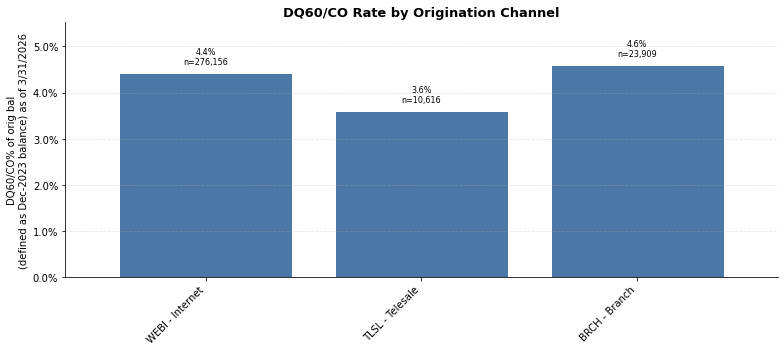

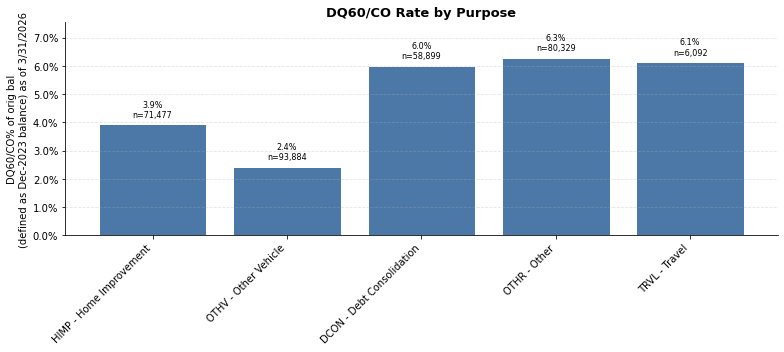

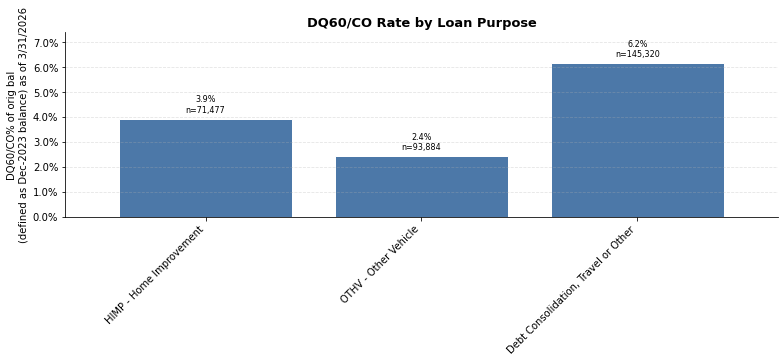

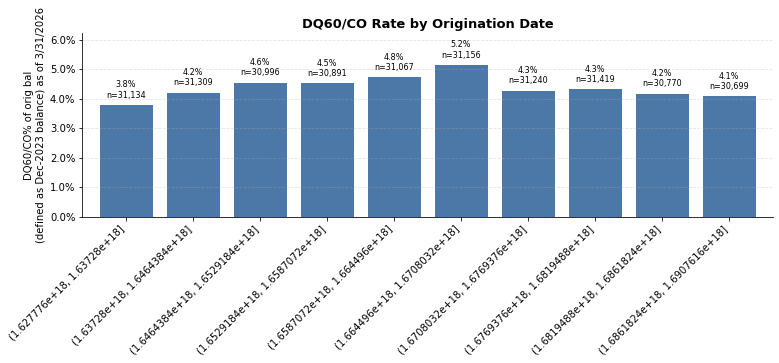

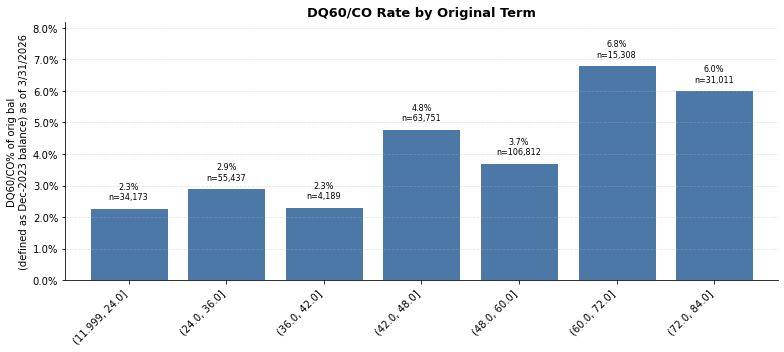

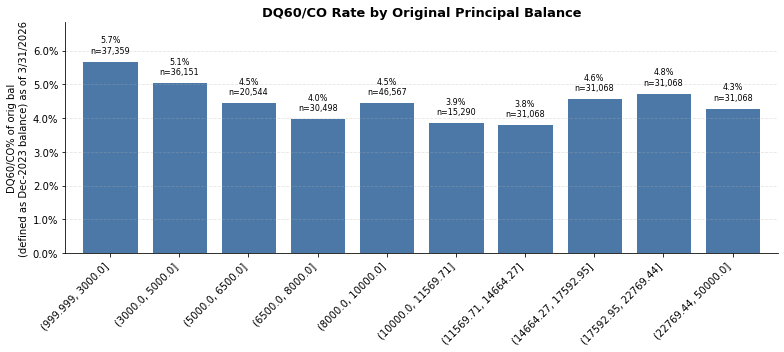

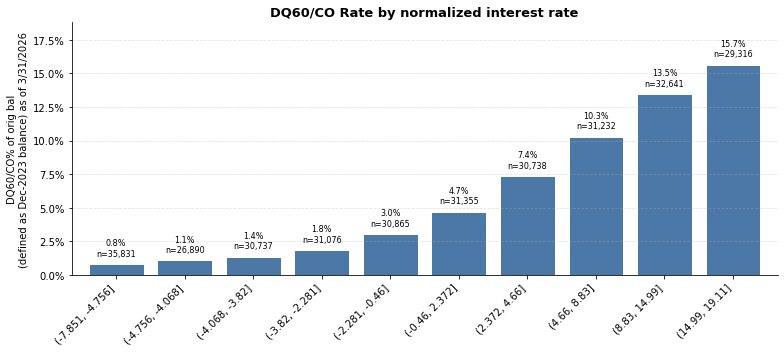

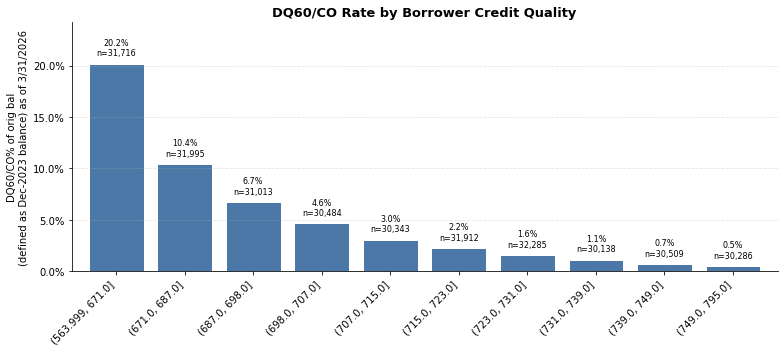

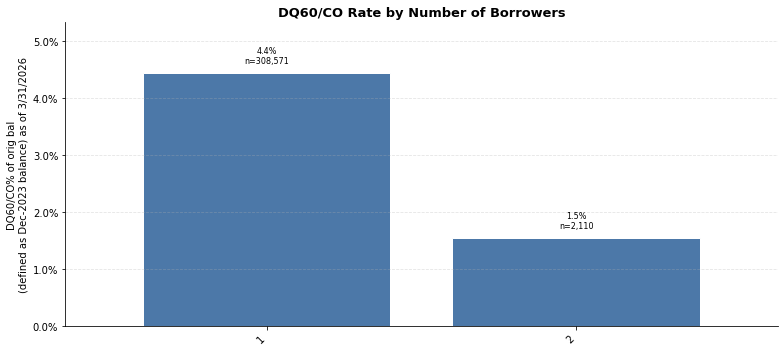

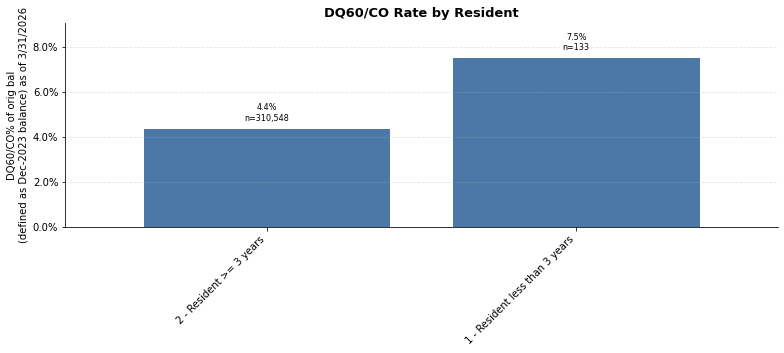

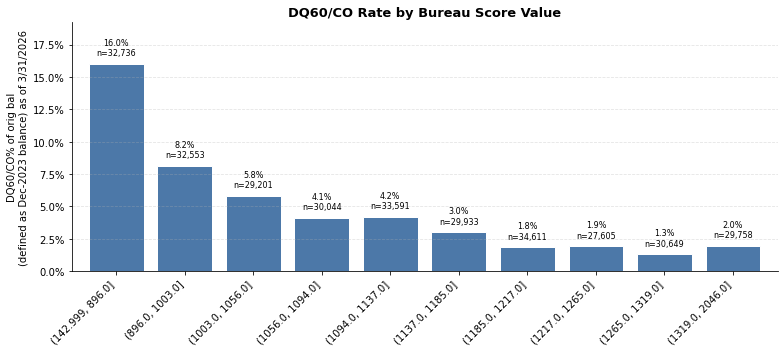

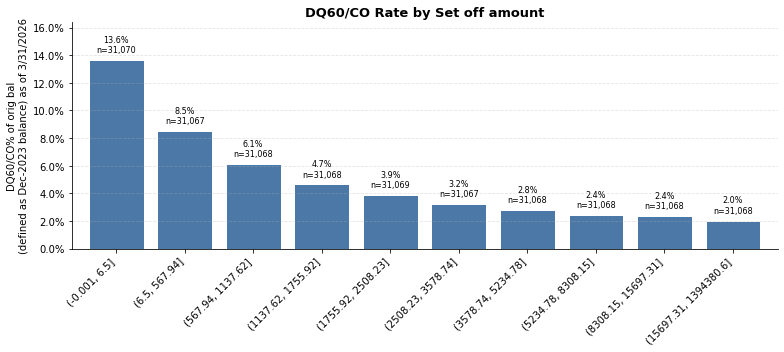

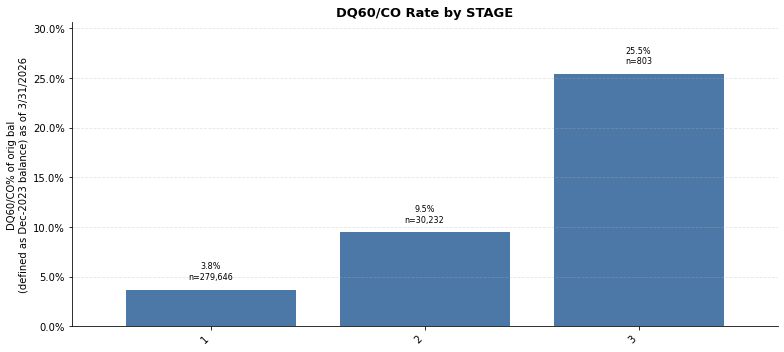

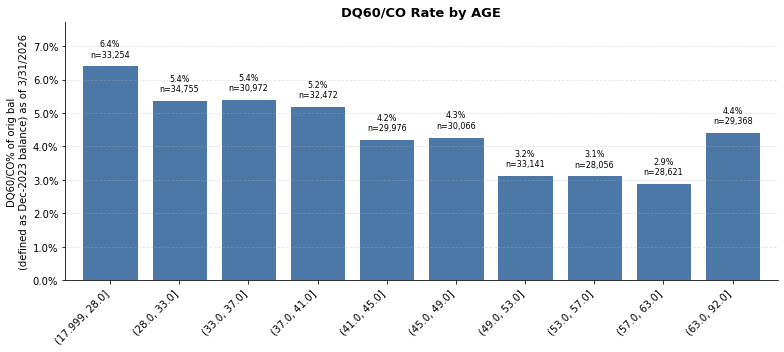

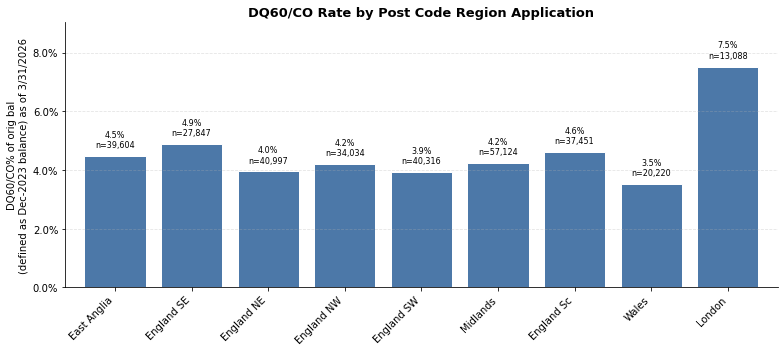

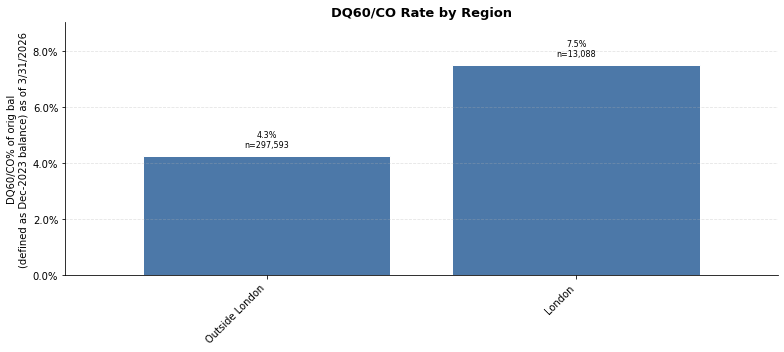

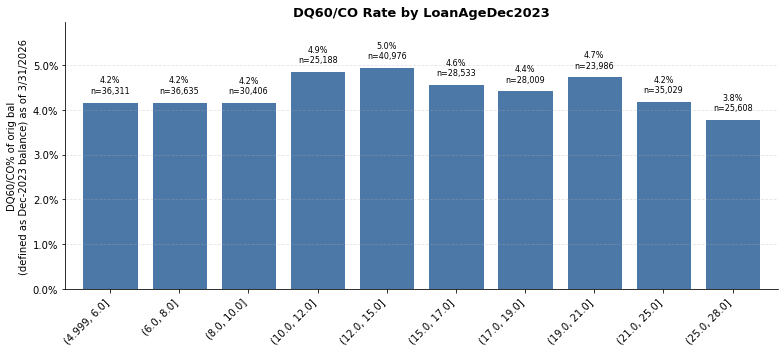

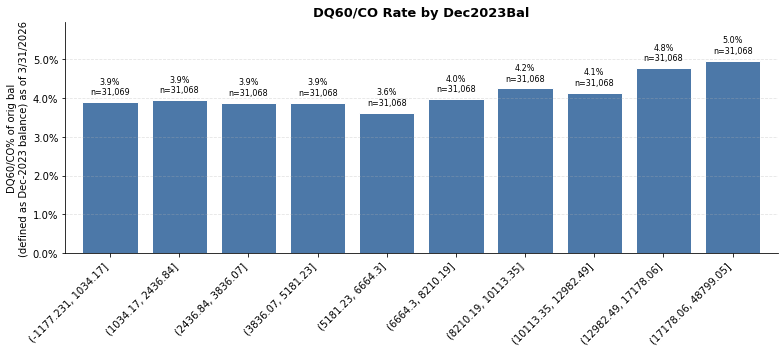

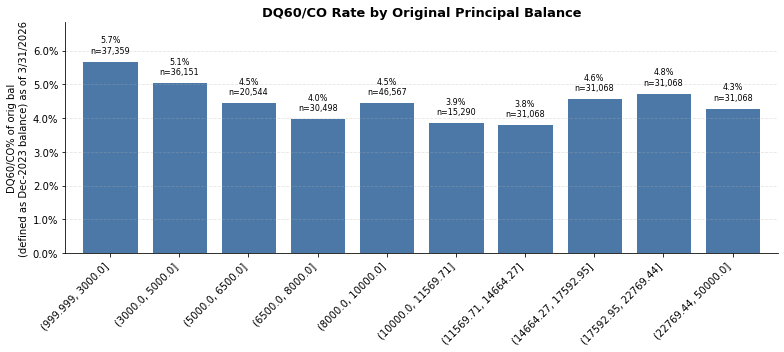

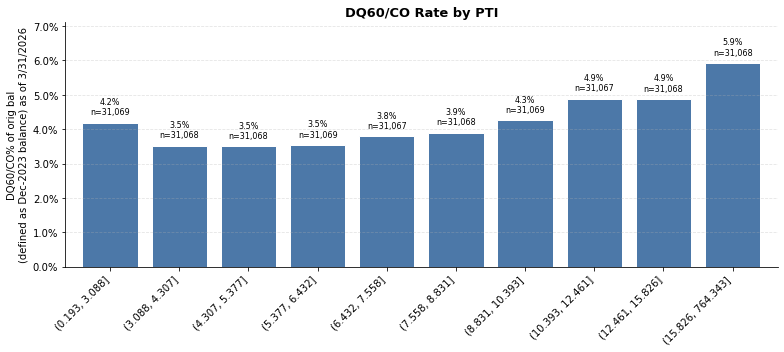

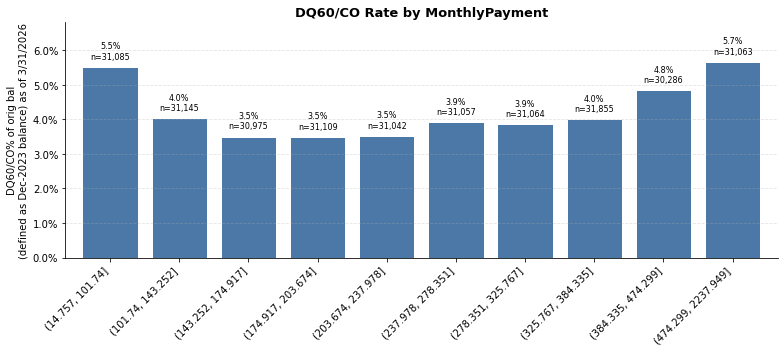

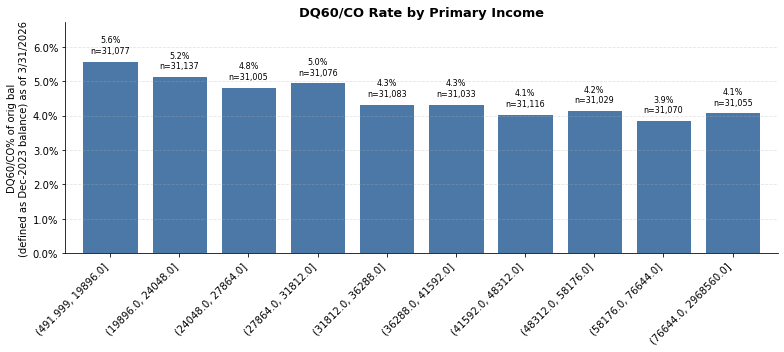

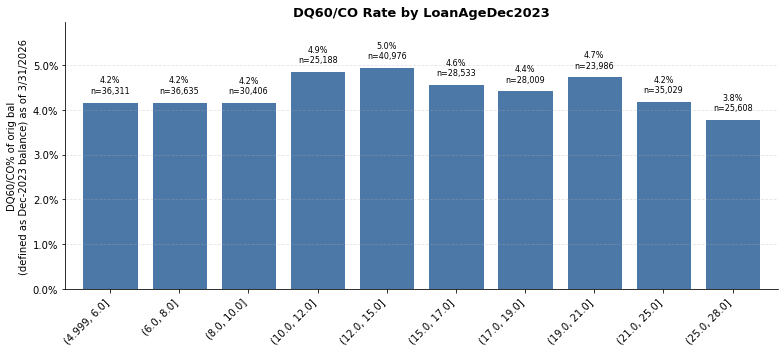

In [8]:
plot_everD60_by_features(df, everD60_col='EverD60CO_Mar2026')

In [9]:
LoanTape['Number of Borrowers'].value_counts()

Number of Borrowers
1    308571
2      2110
Name: count, dtype: int64

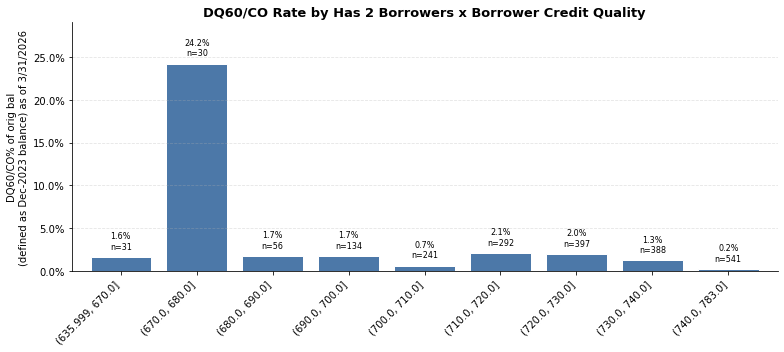

In [10]:
plot_one_visualization(LoanTape[LoanTape['Has 2 Borrowers x Borrower Credit Quality'] > 0], 
                       'Has 2 Borrowers x Borrower Credit Quality', 
                       everD60_col='EverD60CO_Mar2026',
                       breakpoints=[670, 680, 690, 700, 710, 720, 730, 740])

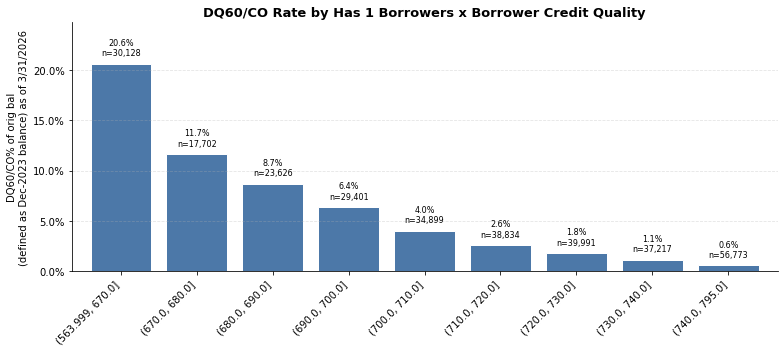

In [11]:
plot_one_visualization(LoanTape[LoanTape['Has 1 Borrowers x Borrower Credit Quality'] > 0], 
                       'Has 1 Borrowers x Borrower Credit Quality', everD60_col='EverD60CO_Mar2026',
                       breakpoints=[670, 680, 690, 700, 710, 720, 730, 740])

In [12]:
# df.groupby('STAGE').agg({'Borrower Credit Quality': ['count', 'min', 'max']}).reset_index()

In [13]:
# df.groupby('STAGE').min()['Borrower Credit Quality'].reset_index()

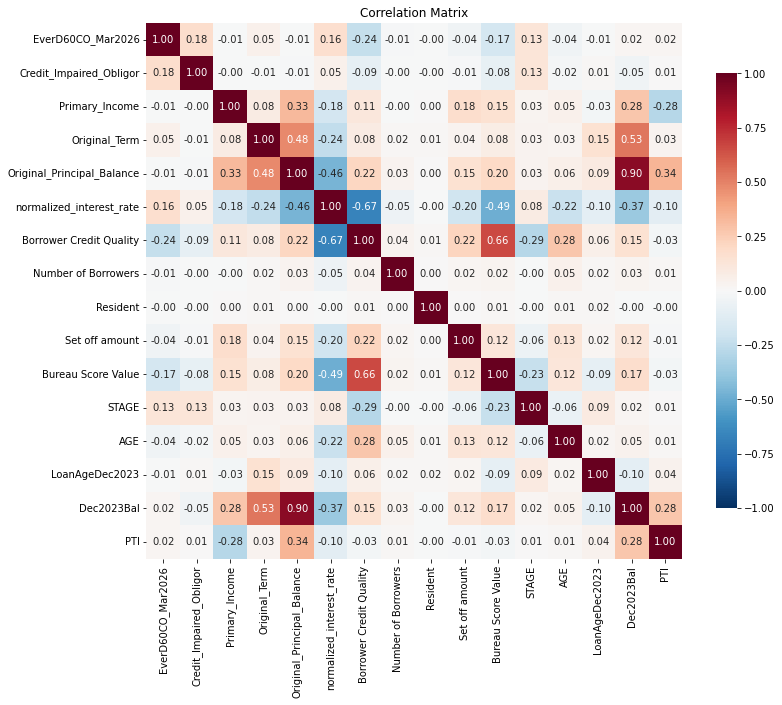

,EverD60CO_Mar2026,Credit_Impaired_Obligor,Primary_Income,Original_Term,Original_Principal_Balance,normalized_interest_rate,Borrower Credit Quality,Number of Borrowers,Resident,Set off amount,Bureau Score Value,STAGE,AGE,LoanAgeDec2023,Dec2023Bal,PTI
EverD60CO_Mar2026,1.000000,0.175913,-0.007764,0.047476,-0.006329,0.164259,-0.239917,-0.012067,-0.001949,-0.044572,-0.172826,0.125684,-0.043607,-0.006522,0.016730,0.021731
Credit_Impaired_Obligor,0.175913,1.000000,-0.004104,-0.006212,-0.010706,0.049142,-0.091699,-0.003236,-0.003173,-0.013606,-0.082439,0.132770,-0.020860,0.012079,-0.046669,0.006900
Primary_Income,-0.007764,-0.004104,1.000000,0.081876,0.327760,-0.183167,0.112287,-0.001614,0.001047,0.178085,0.150462,0.025673,0.047656,-0.028000,0.279260,-0.284123
Original_Term,0.047476,-0.006212,0.081876,1.000000,0.480648,-0.244019,0.081461,0.015606,0.008607,0.035856,0.075092,0.033440,0.029899,0.153794,0.531260,0.033572
Original_Principal_Balance,-0.006329,-0.010706,0.327760,0.480648,1.000000,-0.461457,0.217897,0.034770,0.001137,0.154064,0.201765,0.032816,0.060970,0.091774,0.900870,0.337618
normalized_interest_rate,0.164259,0.049142,-0.183167,-0.244019,-0.461457,1.000000,-0.666201,-0.051168,-0.001114,-0.198004,-0.486024,0.079633,-0.220072,-0.099893,-0.368508,-0.101992
Borrower Credit Quality,-0.239917,-0.091699,0.112287,0.081461,0.217897,-0.666201,1.000000,0.036850,0.010838,0.218836,0.656731,-0.286936,0.278210,0.060775,0.150528,-0.026467
Number of Borrowers,-0.012067,-0.003236,-0.001614,0.015606,0.034770,-0.051168,0.036850,1.000000,0.001711,0.016426,0.023468,-0.002041,0.052313,0.015486,0.029491,0.014025
Resident,-0.001949,-0.003173,0.001047,0.008607,0.001137,-0.001114,0.010838,0.001711,1.000000,0.000288,0.011510,-0.001183,0.009300,0.015238,-0.000935,-0.002307
Set off amount,-0.044572,-0.013606,0.178085,0.035856,0.154064,-0.198004,0.218836,0.016426,0.000288,1.000000,0.122983,-0.058151,0.126499,0.018949,0.121067,-0.010343


In [14]:
cols_for_corr =  [  
    'EverD60CO_Mar2026',
    'Employment_Status',
    'Credit_Impaired_Obligor',
    'Primary_Income',
    'Origination_Channel',
    'Purpose',
    'Original_Term',
    'Original_Principal_Balance',
    'normalized_interest_rate',
    'Borrower Credit Quality',
    'Number of Borrowers',
    'Resident',
    'Set off amount',
    'Bureau Score Value',
    'STAGE',
    'AGE',
    'Post Code Region Application',
    'LoanAgeDec2023',
    'Dec2023Bal',
    'PTI'
]

#remove ctegorical columns for correlation matrix
plot_correlation_simple(df, cols_for_corr)

### Yuemeng Regression Model

#### Version One: include interest rate in the regression

In [15]:
# LoanTape[LoanTape['Number of Borrowers']== 2]

In [93]:
cols = ["EverD60CO_Sep2025",
        
        "New_Underlying_Exposure_Identifier",
        "EverD60CO_Mar2026",
        # "Credit_Impaired_Obligor",
        "Primary_Income",
        "Origination_Channel_Bucket",
        # "Origination_Date",
        "Original_Term",
        "Original_Principal_Balance",
        "normalized_interest_rate",
        "Borrower Credit Quality",
        "Number of Borrowers",
        "Resident_Bucket",
        "Bureau Score Value",
        "STAGE",
        "AGE",
        
        
        "LoanAgeDec2023",
        "Dec2023Bal",
        'PTI',
        'Set off amount',
        'MonthlyPayment',

        "Employment_Status_Bucket",
        "Self_Employed_or_Not", 
        "Purpose_Bucket",
        "Loan_Purpose_Mapped_Bucket",
        "Loan_Purpose",

        "Post Code Region Application_Bucket",
        "Region",

        # test crossing number of borrowers and borrower credit quality
        'Has 2 Borrowers x Borrower Credit Quality',
        'Has 1 Borrowers x Borrower Credit Quality'
    ]

df_training = LoanTape[cols].copy()
df_training['Age Bkt'] = pd.cut(df_training['AGE'], bins=[df_training['AGE'].min(), 50, 60, 70, 80, df_training['AGE'].max()+1], right=False, include_lowest = True)
df_training['Age Bkt'] = df_training['Age Bkt'].astype(str)

In [258]:
# np.mean(LoanTape['Dec2023Bal'])

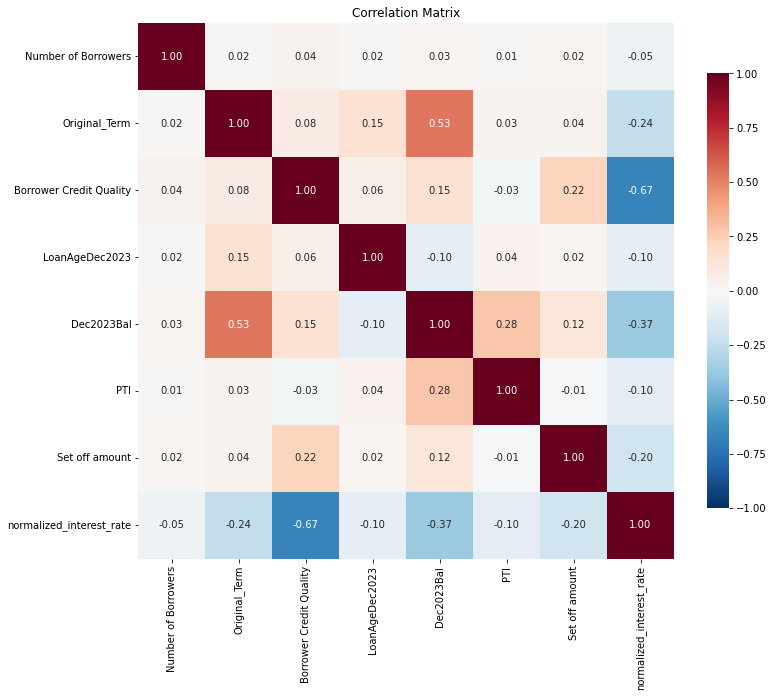

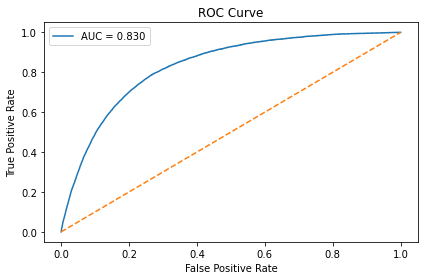

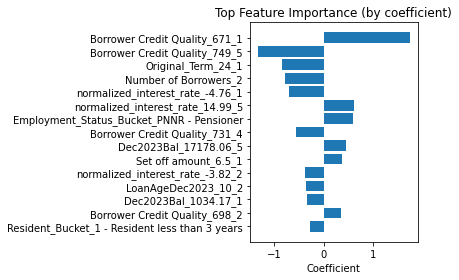

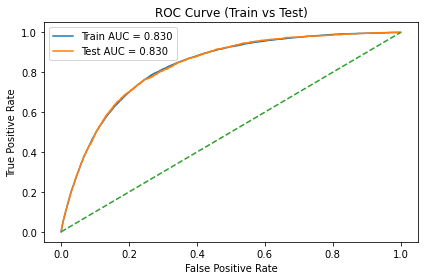

In [236]:
categorical_features = [   
                    "Origination_Channel_Bucket",
                    "Number of Borrowers",
                    "Resident_Bucket",
                    "Post Code Region Application_Bucket",
                    "Loan_Purpose_Mapped_Bucket",
                    "Employment_Status_Bucket",
                    # "STAGE",
                    # # Remove STAGE from categorical features as it is unclear what is the meaning of STAGE

                    # 'Age Bkt'

                    # "Region",
                    # "Loan_Purpose",
                    # "Self_Employed_or_Not",
                       ]

numeric_features = []

percentiles = [10,30,50,70,90]

piecewise_features = [
                'Original_Term',
                'Borrower Credit Quality',
                'LoanAgeDec2023',
                'Dec2023Bal',
                'PTI',
                'Set off amount',
                'normalized_interest_rate',
                
                # # # We choose to remove normalized_interest_rate from the model and fit it in the residual model.
                
                # # 'Bureau Score Value',
                # # # highly correlated with Borrower Credit Quality, so we choose to remove it from the model
                
                # 'AGE',
                # # # likely won't be able to use AGE due to compliance reasons, so we choose to remove it from the model

                # # 'Original_Principal_Balance',
                # # # We choose to use Dec2023Bal instead of Original_Principal_Balance as it is more relevant to the current balance of the loan
                
                # # 'Primary_Income',
                # # 'MonthlyPayment'
                # # # We choose to use PTI instead of MonthlyPayment as it is more relevant to the current payment of the loan
                ]

spline_features = create_spline_features_inputs(df_training, piecewise_features, percentiles)
# spline_features['AGE'] = [60, 70, 80, 85] 
# spline_features['Has 2 Borrowers x Borrower Credit Quality'] = [0, 560, 670, 700, 715, 730, 750]
# spline_features['Has 1 Borrowers x Borrower Credit Quality'] = [0, 560, 670, 700, 715, 730, 750] 

manual_baseline = { }


results = run_model_pipeline(
    df = df_training,
    target_col="EverD60CO_Sep2025",
    categorical_features=categorical_features,
    numeric_features=numeric_features,
    spline_features=spline_features, 
    manual_baseline = manual_baseline,
    model_type="logistic",
    
    test_size=0.2, # 20% of the data will be used for testing
    df_test = None, # using training data as test data for coefficient analysis since we don't have enough data for testing
    test_target_col = "EverD60CO_Mar2026", 
    
    max_categories=10,
    plot_top_n_features =15,
    random_state=42,
    
    plot=True,
    output_coef=False,
    output_file_name="Regression_Coefficients.xlsx",
    id_col='New_Underlying_Exposure_Identifier',
    # adjust_logistic_decision_threshold = 0.125,
    intercept_multiplier = 1
)

In [227]:
results['coef_df']

,Feature,Coefficient,Count,P Value,Std Error,Z-Stat,CI lower,CI upper
0,Origination_Channel_Bucket_WEBI - Internet,0.000000,220961.0,NaN,NaN,NaN,NaN,NaN
1,Origination_Channel_Bucket_BRCH - Branch,0.009090,19050.0,0.833127,0.043142,0.210693,-0.075466,0.093646
2,Origination_Channel_Bucket_TLSL - Telesale,0.075410,8533.0,0.288188,0.071000,1.062105,-0.063748,0.214568
3,Number of Borrowers_1,0.000000,246859.0,NaN,NaN,NaN,NaN,NaN
4,Number of Borrowers_2,-0.943241,1685.0,0.000767,0.280361,-3.364382,-1.492738,-0.393744
...,...,...,...,...,...,...,...,...
61,AGE_80_3,0.000000,4610.0,NaN,NaN,NaN,NaN,NaN
54,AGE_85_4,0.876197,369.4,0.002815,0.293311,2.987266,0.301319,1.451075
62,Intercept,-2.963345,NaN,0.000000,0.152968,-19.372327,-3.263157,-2.663533
63,Accuracy,0.964022,NaN,NaN,NaN,NaN,NaN,NaN


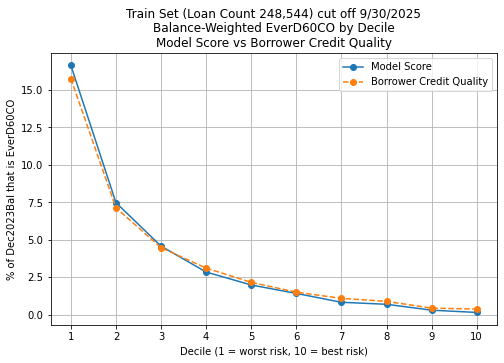

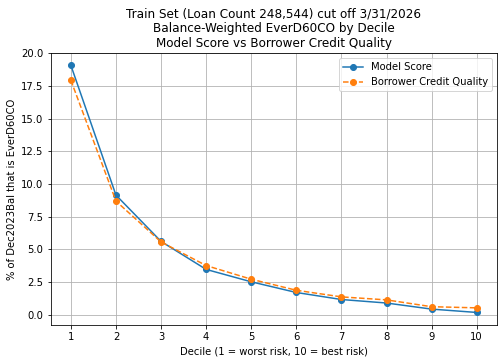

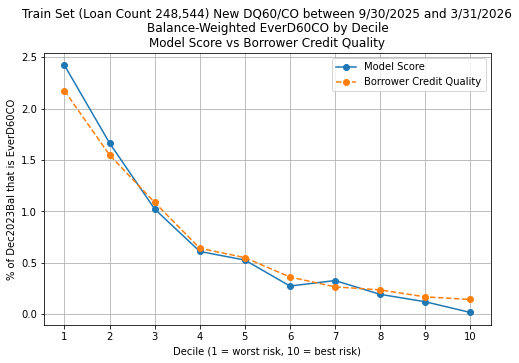

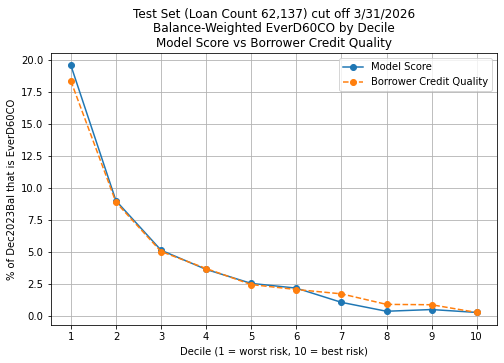

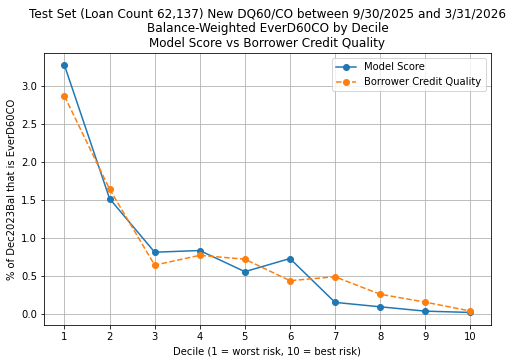

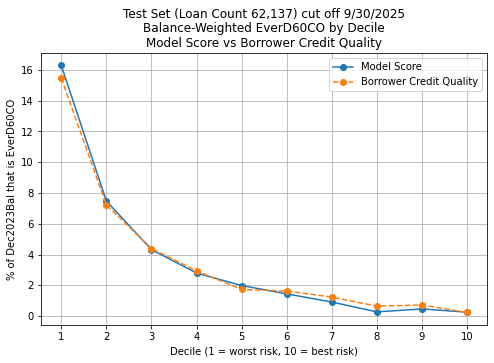

In [216]:
test_result = results['X_test_with_preds'].copy()
train_result = results['X_train_with_preds'].copy()

plot_all_prediction_results(df, test_result, train_result, score_col='y_pred', bal_col='Dec2023Bal', n_deciles=10)

In [217]:
# agg_model_test, agg_bcq_test = plot_prediction_results(test_result, bal_col='Dec2023Bal', bad_col='y_true', n_deciles=10, 
#                                                         title = 'Test Set (Loan Count {:,.0f}) cut off 3/31/2026\nBalance-Weighted EverD60CO by Decile\nModel Score vs Borrower Credit Quality'.format(len(test_result)))

In [237]:
auc_drop_res = auc_drop_test(df_training, 
                            'EverD60CO_Sep2025', 
                            categorical_features, 
                            numeric_features, 
                            spline_features, 
                            manual_baseline,
                            model_type="logistic",
                            test_size=0,
                            max_categories=10,
                            random_state=42)

In [238]:
auc_drop_res
# .to_excel("Outputs/AUC_Drop_Results_Sep2025_Data_final_with_int_rate_v3.xlsx", index=False)


,Variables,AUC w/o Variable,Base AUC,AUC Drop,Ranking
0,Borrower Credit Quality,0.796526,0.830146,-0.03362,1
1,normalized_interest_rate,0.825884,0.830146,-0.004262,2
2,Original_Term,0.826282,0.830146,-0.003863,3
3,Employment_Status_Bucket,0.82795,0.830146,-0.002196,4
4,Dec2023Bal,0.828066,0.830146,-0.00208,5
5,Set off amount,0.828392,0.830146,-0.001754,6
6,Loan_Purpose_Mapped_Bucket,0.828626,0.830146,-0.001519,7
7,LoanAgeDec2023,0.829468,0.830146,-0.000678,8
8,Post Code Region Application_Bucket,0.829764,0.830146,-0.000382,9
9,PTI,0.829989,0.830146,-0.000156,10


#### Version 2: regression inverest rate in the residual

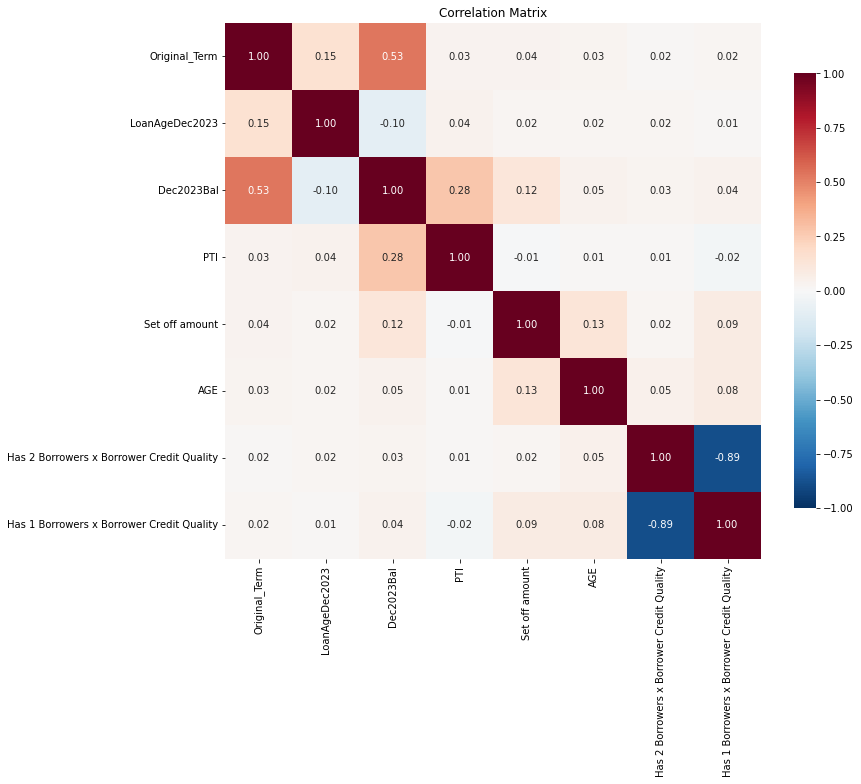

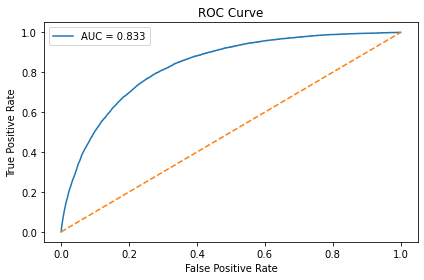

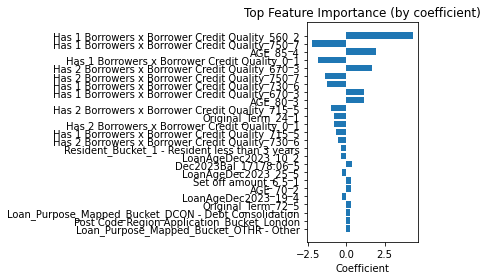

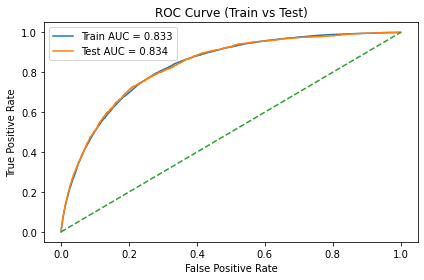

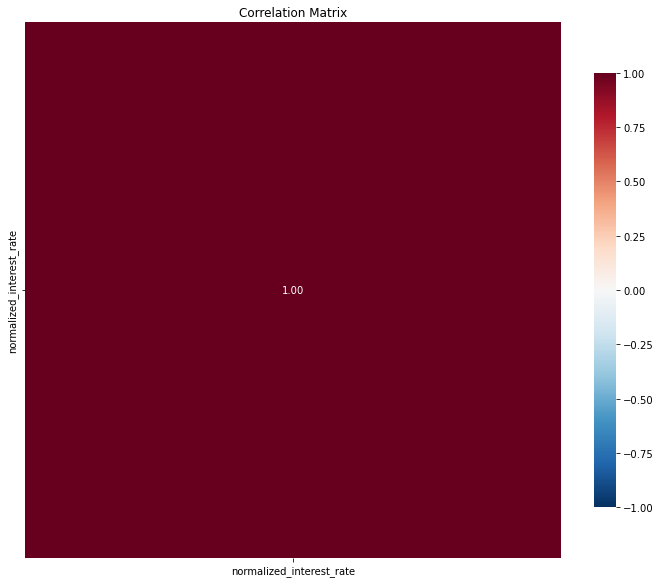

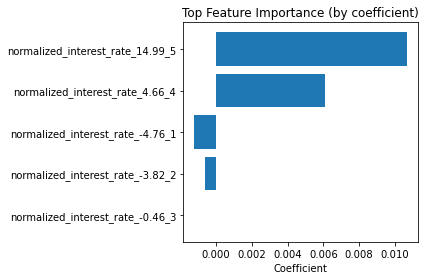

In [239]:
# -------------------------
# Stage 1: fundamental factors
# -------------------------


base_categorical_features  = [   
                    "Origination_Channel_Bucket",
                    # "Number of Borrowers",
                    "Resident_Bucket",
                    "Post Code Region Application_Bucket",
                    "Loan_Purpose_Mapped_Bucket",
                    "Employment_Status_Bucket",
                    # "STAGE",
                    # # Remove STAGE from categorical features as it is unclear what is the meaning of STAGE

                    # "Age Bkt"

                    # "Region",
                    # "Loan_Purpose",
                    # "Self_Employed_or_Not",
                       ]

base_numeric_features = []

percentiles = [10,30,50,70,90]

base_piecewise_features = [
                'Original_Term',
                # 'Borrower Credit Quality',
                'LoanAgeDec2023',
                'Dec2023Bal',
                'PTI',
                'Set off amount',
                # 'normalized_interest_rate',
                
                # # # We choose to remove normalized_interest_rate from the model and fit it in the residual model.
                
                # # 'Bureau Score Value',
                # # # highly correlated with Borrower Credit Quality, so we choose to remove it from the model
                
                # # # 'AGE',
                # # # likely won't be able to use AGE due to compliance reasons, so we choose to remove it from the model

                # # 'Original_Principal_Balance',
                # # # We choose to use Dec2023Bal instead of Original_Principal_Balance as it is more relevant to the current balance of the loan
                
                # # 'Primary_Income',
                # # 'MonthlyPayment'
                # # # We choose to use PTI instead of MonthlyPayment as it is more relevant to the current payment of the loan
                ]

base_spline_features = create_spline_features_inputs(df_training, base_piecewise_features, percentiles)
base_spline_features['AGE'] = [60, 70, 80, 85] 
base_spline_features['Has 2 Borrowers x Borrower Credit Quality'] = [0, 560, 670, 700, 715, 730, 750]
base_spline_features['Has 1 Borrowers x Borrower Credit Quality'] = [0, 560, 670, 700, 715, 730, 750] 

base_manual_baseline = None
base_spline_manual_baseline={
        "AGE": 60,
    }


# base_categorical_features = [   
#                     "Origination_Channel_Bucket",
#                     "Number of Borrowers",
#                     "Resident_Bucket",
#                     "Post Code Region Application_Bucket",
#                     "Loan_Purpose_Mapped_Bucket",
#                     "Employment_Status_Bucket",
#                     # "STAGE",
#                     # # Remove STAGE from categorical features as it is unclear what is the meaning of STAGE

#                     # "Region",
#                     # "Loan_Purpose",
#                     # "Self_Employed_or_Not",
#                        ]

# base_numeric_features = []

# base_piecewise_features = [
#                 'Original_Term',
#                 'Borrower Credit Quality',
#                 'LoanAgeDec2023',
#                 'Dec2023Bal',
#                 'PTI',
#                 'Set off amount',
#                 # 'normalized_interest_rate',
#                 # # We choose to remove normalized_interest_rate from the model and fit it in the residual model.
                
#                 # 'Bureau Score Value',
#                 # # highly correlated with Borrower Credit Quality, so we choose to remove it from the model
                
#                 # 'AGE',
#                 # # likely won't be able to use AGE due to compliance reasons, so we choose to remove it from the model

#                 # 'Original_Principal_Balance',
#                 # # We choose to use Dec2023Bal instead of Original_Principal_Balance as it is more relevant to the current balance of the loan
                
#                 # 'Primary_Income',
#                 # 'MonthlyPayment'
#                 # # We choose to use PTI instead of MonthlyPayment as it is more relevant to the current payment of the loan
#                 ]

# base_spline_features = create_spline_features_inputs(df_training, base_piecewise_features, percentiles = [10,30,50,70,90])

# base_manual_baseline=None

# -------------------------
# Stage 2: residual / overlay factors
# -------------------------
residual_categorical_features = []

residual_numeric_features = []

residual_piecewise_features = ["normalized_interest_rate"]

residual_spline_features = create_spline_features_inputs(df_training, residual_piecewise_features, percentiles = [10,30,50,70,90])

residual_manual_baseline=None # categorical features 
residual_spline_manual_baseline = None # spline features

# -------------------------
# Run two-layer model
# -------------------------
residual_results = run_residual_layer_pipeline(
    df=df_training,
    target_col="EverD60CO_Sep2025",

    base_categorical_features=base_categorical_features,
    base_numeric_features=base_numeric_features,
    base_spline_features=base_spline_features,

    residual_categorical_features=residual_categorical_features,
    residual_numeric_features=residual_numeric_features,
    residual_spline_features=residual_spline_features,

    base_manual_baseline=base_manual_baseline,
    residual_manual_baseline=residual_manual_baseline,

    base_spline_manual_baseline=base_spline_manual_baseline,
    residual_spline_manual_baseline=residual_spline_manual_baseline,

    base_model_type="logistic",
    residual_model_type="linear",

    test_size=0.2,
    df_test=None,  # or your true OOS dataframe
    test_target_col="EverD60CO_Sep2025",

    max_categories=10,
    plot=True,
    output_coef=True,
    id_col='New_Underlying_Exposure_Identifier'  # remove or change if your ID column has a different name
)

In [240]:
stage_1_logistic_regression_res = residual_results['stage1_results']['coef_df']
stage_1_logistic_regression_res.iloc[:, :] 

,Feature,Coefficient,Count,P Value,Std Error,Z-Stat,CI lower,CI upper
0,Origination_Channel_Bucket_WEBI - Internet,0.000000,220961.000000,NaN,NaN,NaN,NaN,NaN
1,Origination_Channel_Bucket_BRCH - Branch,0.045850,19050.000000,0.288374,0.043185,1.061695,-0.038792,0.130492
2,Origination_Channel_Bucket_TLSL - Telesale,0.097178,8533.000000,0.171732,0.071106,1.366660,-0.042188,0.236544
3,Resident_Bucket_2 - Resident >= 3 years,0.000000,248428.000000,NaN,NaN,NaN,NaN,NaN
4,Resident_Bucket_1 - Resident less than 3 years,-0.382208,116.000000,0.493747,0.558489,-0.684361,-1.476826,0.712410
...,...,...,...,...,...,...,...,...
56,Has 1 Borrowers x Borrower Credit Quality_730_6,-1.289380,52962.183333,0.000000,0.066795,-19.303573,-1.420296,-1.158465
57,Has 1 Borrowers x Borrower Credit Quality_750_7,-2.266647,47784.950000,0.000000,0.096121,-23.581289,-2.455040,-2.078254
66,Intercept,-2.660732,NaN,0.000000,0.224498,-11.851933,-3.100739,-2.220724
67,Accuracy,0.963922,NaN,NaN,NaN,NaN,NaN,NaN


In [241]:
stage_2_linear_regression_res = residual_results['stage2_results']['coef_df']
stage_2_linear_regression_res

,Feature,Coefficient,Count,P Value,Std Error,T-Stat,CI lower,CI upper
0,normalized_interest_rate_-4.76_1,-0.001226,41586.941051,4.050446e-01,0.001472,-0.832647,-0.004111,0.001659
1,normalized_interest_rate_-3.82_2,-0.000590,59860.325553,7.176073e-01,0.001632,-0.361659,-0.003788,0.002608
4,normalized_interest_rate_-0.46_3,0.000000,45887.674881,NaN,NaN,NaN,NaN,NaN
2,normalized_interest_rate_4.66_4,0.006071,54486.183749,4.643008e-04,0.001734,3.500596,0.002672,0.009471
3,normalized_interest_rate_14.99_5,0.010668,46722.874767,1.056932e-13,0.001435,7.433941,0.007855,0.013480
5,Intercept,-0.003001,NaN,9.211363e-03,0.001152,-2.604129,-0.005259,-0.000742
6,R²,0.000589,NaN,NaN,NaN,NaN,NaN,NaN


In [242]:
# stage_1_logistic_regression_res.to_excel("Outputs/Stage_1_Logistic_Regression_Coefficients_Sep2025_Data_final_with_int_rate_v6.30.2026_v4.xlsx", index=False)
# stage_2_linear_regression_res.to_excel("Outputs/Stage_2_Linear_Regression_Coefficients_Sep2025_Data_final_with_int_rate_v6.30.2026_v4.xlsx", index=False)

In [245]:
res_train_plot_sep2025 = return_combined_results_for_plotting(residual_results, df, 
                                                              result_data = 'combined_train_with_preds',
                                                                bad_col='EverD60CO_Sep2025',
                                                                bal_col='Dec2023Bal',
                                                                lloyds_score_col='Borrower Credit Quality',
                                                                n_deciles=10)

res_train_plot_mar2026 = return_combined_results_for_plotting(residual_results, df, 
                                                              result_data = 'combined_train_with_preds',
                                                                bad_col='EverD60CO_Mar2026',
                                                                bal_col='Dec2023Bal',
                                                                lloyds_score_col='Borrower Credit Quality',
                                                                n_deciles=10)
                                    
res_test_plot_mar2026 = return_combined_results_for_plotting(residual_results, df, 
                                                             result_data = 'combined_test_with_preds',
                                                            bad_col='EverD60CO_Mar2026',
                                                            bal_col='Dec2023Bal',
                                                            lloyds_score_col='Borrower Credit Quality',
                                                            n_deciles=10)

res_test_plot_new_default = return_combined_results_for_plotting(residual_results, df, 
                                                             result_data = 'combined_test_with_preds',
                                                            bad_col='new_default_flag',
                                                            bal_col='Dec2023Bal',
                                                            lloyds_score_col='Borrower Credit Quality',
                                                            n_deciles=10)

In [246]:
residual_results['stage2_results']['X_train_with_preds']

,normalized_interest_rate,New_Underlying_Exposure_Identifier,y_true,y_pred
67550,-3.931489,1388583237,-0.001054,-0.003666
11805,-3.350004,1373277996,-0.001953,-0.003508
77869,-4.547819,1390663364,-0.002623,-0.004083
59955,-4.901489,1386911458,-0.001163,-0.004226
166243,-3.439696,1409272338,-0.015912,-0.003524
...,...,...,...,...
119879,1.789177,1397917645,-0.007578,-0.000333
259178,3.643549,1427757387,-0.072218,0.001865
131932,-5.430823,1400019984,-0.009810,-0.004226
146867,-3.990823,1405080764,-0.005767,-0.003706


In [247]:
# plot_df_all_test = plot_df.copy()

# # new_res_test_plot_mar2026 = res_test_plot_mar2026.copy()
# # res_test_plot_new_default_old = res_test_plot_new_default.copy()

# plot_df = res_test_plot_new_default_old.join(res_test_plot_new_default, lsuffix='_old', rsuffix='_new')

# # plot_df = res_test_plot_mar2026.join(new_res_test_plot_mar2026, lsuffix='_old', rsuffix='_new')

# plt.figure(figsize=(10, 6))

# plt.plot(
#     plot_df['decile_old'].to_numpy(),
#     plot_df['Stage 2: Stage 1 + Interest Rate Residual Model_old'].to_numpy(),
#     marker='o',
#     label='Old Model w/o Borrower Age'
# )

# plt.plot(
#     plot_df['decile_new'].to_numpy(),
#     plot_df['Stage 2: Stage 1 + Interest Rate Residual Model_new'].to_numpy(),
#     marker='o',
#     linestyle='-',
#     label='New Model w/ Borrower Age'
# )

# plt.plot(
#     plot_df['decile_old'].to_numpy(),
#     plot_df['Lloyds Score: Borrower Credit Quality_old'].to_numpy(),
#     marker='o',
#     linestyle='--',
#     label='Lloyds Score: Borrower Credit Quality'
# )

# plt.xlabel('Decile (1 = worst risk, 10 = best risk)')
# plt.ylabel(f'% of Dec2023 Bal that is EverD60CO')
# plt.title('Test Set (Loan Count {:,.0f}) cut off 03/31/2026\nBalance-Weighted EverD60+/CO by Decile\nModel Score vs Borrower Credit Quality'.format(len(residual_results['combined_test_with_preds'])))
# plt.grid(True)
# plt.xticks(range(1, len(plot_df['decile_old'].to_numpy()) + 1))
# plt.legend()
# plt.show()

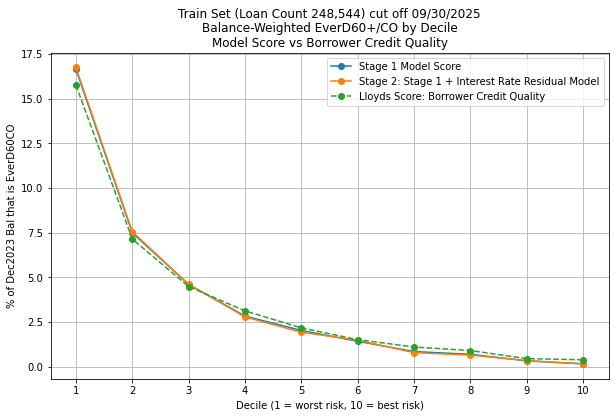

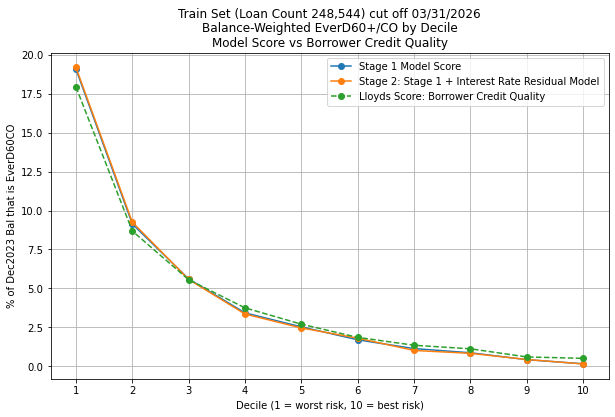

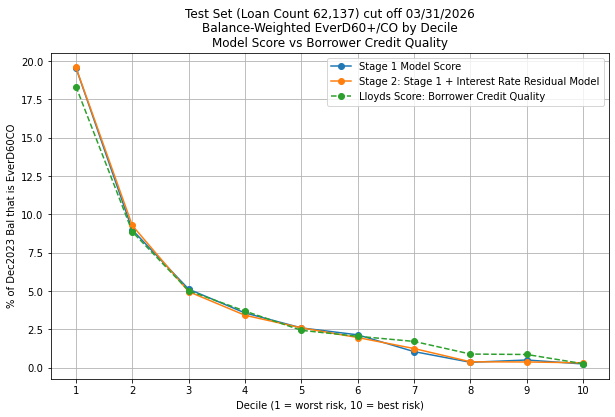

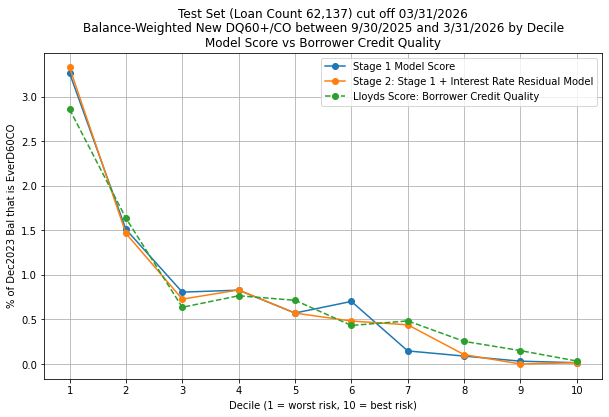

In [248]:
plot_stage_1_2_compare(res_train_plot_sep2025, 
                       title = 'Train Set (Loan Count {:,.0f}) cut off 09/30/2025\nBalance-Weighted EverD60+/CO by Decile\nModel Score vs Borrower Credit Quality'.format(len(residual_results['combined_train_with_preds'])))
plot_stage_1_2_compare(res_train_plot_mar2026, 
                       title = 'Train Set (Loan Count {:,.0f}) cut off 03/31/2026\nBalance-Weighted EverD60+/CO by Decile\nModel Score vs Borrower Credit Quality'.format(len(residual_results['combined_train_with_preds'])))
plot_stage_1_2_compare(res_test_plot_mar2026, 
                       title = 'Test Set (Loan Count {:,.0f}) cut off 03/31/2026\nBalance-Weighted EverD60+/CO by Decile\nModel Score vs Borrower Credit Quality'.format(len(residual_results['combined_test_with_preds'])))
plot_stage_1_2_compare(res_test_plot_new_default, 
                       title = 'Test Set (Loan Count {:,.0f}) cut off 03/31/2026\nBalance-Weighted New DQ60+/CO between 9/30/2025 and 3/31/2026 by Decile\nModel Score vs Borrower Credit Quality'.format(len(residual_results['combined_test_with_preds'])))

In [249]:
train_res = residual_results['combined_train_with_preds'][['New_Underlying_Exposure_Identifier', residual_results['combined_pred_col']]]
test_res = residual_results['combined_test_with_preds'][['New_Underlying_Exposure_Identifier', residual_results['combined_pred_col']]]
combined_pred_res = pd.concat([train_res, test_res], axis=0)
combined_pred_res = add_additional_columns_for_plotting_prediction_results(df, combined_pred_res, bal_col='Dec2023Bal')

In [250]:
(agg_all_data_stage_2_mar2026, 
 agg_bcq_data_stage_2_mar2026, 
 df_sorted_model_data_stage_2_mar2026, 
 df_sorted_bcq_data_stage_2_mar2026) = get_decile_boundaries(combined_pred_res, 
                                                                bal_col='Dec2023Bal', 
                                                                bad_col='EverD60CO_Mar2026',
                                                                score_col=residual_results['combined_pred_col'],  # this is the BV score model column
                                                                lloyds_score_col='Borrower Credit Quality',  # this is the Lloyds score column
                                                                n_deciles=10)

In [251]:
df_sorted_bcq_data_stage_2_mar2026.rename(columns={'decile': 'Borrower_Credit_Quality_Decile'}, inplace=True)
df_sorted_model_data_stage_2_mar2026.rename(columns={'decile': 'PD_Model_Score_Decile'}, inplace=True)

pred_res_df = df_sorted_bcq_data_stage_2_mar2026.merge(df_sorted_model_data_stage_2_mar2026[['New_Underlying_Exposure_Identifier', 'PD_Model_Score_Decile']], 
                                          on = 'New_Underlying_Exposure_Identifier',
                                          how = 'outer')

In [253]:
pred_res_df.head()

,New_Underlying_Exposure_Identifier,Score_model,Borrower Credit Quality,Dec2023Bal,EverD60CO_Mar2026,cum_bal,bal_pct,Borrower_Credit_Quality_Decile,PD_Model_Score_Decile
0,1367789200,-0.000000,747,5132.89,0,2.199104e+09,0.874230,9,10
1,1367789203,-0.000000,740,3060.82,0,1.974732e+09,0.785033,8,10
2,1367789205,-0.016815,715,0.00,0,1.125368e+09,0.447378,5,5
3,1367789209,-0.009202,741,18614.01,0,2.015087e+09,0.801076,9,6
4,1367789214,-0.000000,760,6373.86,0,2.429027e+09,0.965633,10,10
